# Classification Metrics

In [1]:
!pip install numpy pandas matplotlib seaborn scikit_learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = {
    "cgpa": [
        5.8, 6.1, 6.3, 6.5, 6.7, 6.8,
        7.0, 7.1, 7.2, 7.4, 7.5, 7.6,
        7.8, 7.9, 8.0, 8.2, 8.3, 8.4,
        8.5, 8.7, 8.8, 9.0, 9.1, 9.3
    ],
    "dsa_score": [
        30, 35, 38, 42, 45, 48,
        50, 52, 55, 58, 60, 64,
        68, 70, 73, 76, 78, 80,
        83, 85, 88, 90, 92, 95
    ],
    "projects": [
        0, 1, 1, 1, 1, 2,
        1, 2, 2, 2, 3, 2,
        3, 3, 3, 4, 3, 4,
        4, 4, 5, 5, 5, 6
    ],
    "internship": [
        0, 0, 0, 0, 0, 1,
        0, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1
    ],
    "communication_score": [
        38, 42, 45, 48, 50, 52,
        54, 56, 58, 60, 62, 64,
        67, 69, 71, 74, 76, 78,
        80, 83, 85, 88, 90, 94
    ],
    "placed": [
        0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1
    ]
}
df=pd.DataFrame(data)
df

,cgpa,dsa_score,projects,internship,communication_score,placed
0,5.8,30,0,0,38,0
1,6.1,35,1,0,42,0
2,6.3,38,1,0,45,0
3,6.5,42,1,0,48,0
4,6.7,45,1,0,50,0
5,6.8,48,2,1,52,0
6,7.0,50,1,0,54,0
7,7.1,52,2,1,56,0
8,7.2,55,2,0,58,0
9,7.4,58,2,1,60,0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

x=df.drop("placed",axis=1)
y=df["placed"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(
     y_test,
     y_pred,
     labels=[0,1],
)
print("Confusion matrix:")
print(cm)

Confusion matrix:
[[3 0]
 [0 3]]


In [10]:
tn,fp,fn,tp=cm.ravel()
print("True negative:",tn)
print("False Positive",fp)
print("False Negative",fn)
print("True positive",tp)

True negative: 3
False Positive 0
False Negative 0
True positive 3


In [11]:
from sklearn.metrics import (
     accuracy_score,
     precision_score,
     recall_score,
     f1_score
)
acc=accuracy_score(y_test,y_pred)
prec=precision_score(
     y_test,
     y_pred,
     pos_label=1,
     zero_division=0
)
recall=recall_score(
     y_test,
     y_pred,
     pos_label=1,
     zero_division=0
)
f1=f1_score(
     y_test,
     y_pred,
     pos_label=1,
     zero_division=0
)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [13]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return 0.0
    return numerator / denominator
manual_accuracy = safe_divide(
    tp + tn,
    tp + tn + fp + fn
)
manual_precision = safe_divide(
    tp,
    tp + fp
)
manual_recall = safe_divide(
    tp,
    tp + fn
)
manual_f1 = safe_divide(
    2 * manual_precision * manual_recall,
    manual_precision + manual_recall
)
print("Manual Accuracy:", manual_accuracy)
print("Manual Precision:", manual_precision)
print("Manual Recall:", manual_recall)
print("Manual F1:", manual_f1)

Manual Accuracy: 1.0
Manual Precision: 1.0
Manual Recall: 1.0
Manual F1: 1.0


In [14]:
from sklearn.metrics import classification_report
report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Not Placed",
        "Placed"
    ],
    zero_division=0
)
print(report)

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         3
      Placed       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



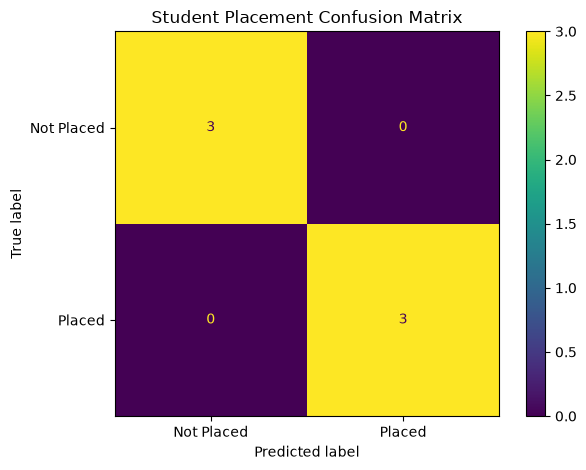

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "Not Placed",
        "Placed"
    ],
    values_format="d"
)

plt.title("Student Placement Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
place_probab=model.predict_proba(
     X_test
)[:,1]
results=X_test.copy()
results["Actual"]=y_test
results["Predicted"]=y_pred
results["Probability_placed"]=place_probab
results["Prediction_Type"] = [
    (
        "TN"
        if actual == 0 and predicted == 0
        else "FP"
        if actual == 0 and predicted == 1
        else "FN"
        if actual == 1 and predicted == 0
        else "TP"
    )
    for actual, predicted in zip(
        results["Actual"],
        results["Predicted"]
    )
]
results


,cgpa,dsa_score,projects,internship,communication_score,Actual,Predicted,Probability_placed,Prediction_Type
6,7.0,50,1,0,54,0,0,0.113531,TN
23,9.3,95,6,1,94,1,1,0.994346,TP
19,8.7,85,4,1,83,1,1,0.949845,TP
14,8.0,73,3,1,71,1,1,0.687796,TP
3,6.5,42,1,0,48,0,0,0.039307,TN
7,7.1,52,2,1,56,0,0,0.106323,TN


In [19]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    (
        "classifier",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

micro_f1 = f1_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Micro F1:", micro_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names,
        zero_division=0
    )
)

Accuracy: 0.9333333333333333
Macro Precision: 0.9444444444444445
Macro Recall: 0.9333333333333332
Macro F1: 0.9326599326599326
Weighted F1: 0.9326599326599326
Micro F1: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [20]:
per_class_precision = precision_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_recall = recall_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_f1 = f1_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_df = pd.DataFrame({
    "Class": iris.target_names,
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1": per_class_f1
})

print(per_class_df)

        Class  Precision  Recall        F1
0      setosa   1.000000     1.0  1.000000
1  versicolor   0.833333     1.0  0.909091
2   virginica   1.000000     0.8  0.888889


In [21]:
per_class_precision = precision_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_recall = recall_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_f1 = f1_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

per_class_df = pd.DataFrame({
    "Class": iris.target_names,
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1": per_class_f1
})

per_class_df

,Class,Precision,Recall,F1
0,setosa,1.000000,1.0,1.000000
1,versicolor,0.833333,1.0,0.909091
2,virginica,1.000000,0.8,0.888889


In [23]:
probab = model.predict_proba(X_test)[:, 1]
th = 0.70
custom_pred = (
    probab >= th
).astype(int)

In [ ]:
threshold_results = []
probabilities = model.predict_proba(X_test)[:, 1]
for threshold in [0.30, 0.50, 0.70]:
    custom_pred = (
        probabilities >= threshold
    ).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            custom_pred
        ),
        "Precision": precision_score(
            y_test,
            custom_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            custom_pred,
            average="macro",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            custom_pred,
            average="macro",
            zero_division=0
        )
    })
print(pd.DataFrame(threshold_results))

   Threshold  Accuracy  Precision    Recall        F1
0        0.3  0.666667   0.452489  0.666667  0.536769
1        0.5  0.666667   0.462963  0.666667  0.541126
2        0.7  0.600000   0.484848  0.600000  0.504630
